# ***SCRAPING DATA***

In [ ]:
!pip install google-play-scraper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.4 MB/s eta 0:00:00


In [ ]:
from google_play_scraper import reviews, Sort

app_id = 'com.bpjstku'

def get_reviews(app_id, lang='id', count=5000, sort=Sort.NEWEST, filter_score_with=None, filter_device_with=None, continuation_token=None):
    try:
        result, continuation_token = reviews(
            app_id,
            lang=lang,
            country='id',
            sort=sort,
            count=count,
            filter_score_with=filter_score_with,
            filter_device_with=filter_device_with,
            continuation_token=continuation_token
        )

        return result, continuation_token
    except Exception as e:
        print("Error:", e)
        return None, None

reviews, continuation_token = get_reviews(app_id)

if reviews is not None:
    print("Jumlah ulasan:", len(reviews))
    if len(reviews) > 0:
        print("Contoh ulasan:")
        print(reviews[0])
else:
    print("Tidak dapat mengambil ulasan.")


Jumlah ulasan: 5000
Contoh ulasan:
{'reviewId': '893b0aec-92d8-4017-ad61-adf91d7f3a5f', 'userName': 'Pengguna Google', 'userImage': 'https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g', 'content': 'error terus uninstall udah 5× lebih', 'score': 1, 'thumbsUpCount': 0, 'reviewCreatedVersion': '4.14.7', 'at': datetime.datetime(2025, 5, 8, 12, 36, 23), 'replyContent': None, 'repliedAt': None, 'appVersion': '4.14.7'}


In [ ]:
import csv

def export_to_csv(reviews, file_name='hasil_scraper_ulasan_app_JMO.csv'):
    if reviews:
        fieldnames = ['Review ID', 'Username', 'Rating', 'Review Text', 'Date']

        with open(file_name, mode='w', newline='', encoding='utf-8') as csv_file:
            writer = csv.DictWriter(csv_file, fieldnames=fieldnames)
            writer.writeheader()

            for review in reviews:
                writer.writerow({
                    'Review ID': review['reviewId'],
                    'Username': review['userName'],
                    'Rating': review['score'],
                    'Review Text': review['content'],
                    'Date': review['at']
                })

        print(f"Data berhasil diekspor ke '{file_name}'")
    else:
        print("Tidak ada data ulasan untuk diekspor.")

export_to_csv(reviews)


Data berhasil diekspor ke 'hasil_scraper_ulasan_app_JMO.csv'


In [ ]:
import pandas as pd

data = pd.read_csv("hasil_scraper_ulasan_app_JMO.csv")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Review ID    5000 non-null   object
 1   Username     5000 non-null   object
 2   Rating       5000 non-null   int64 
 3   Review Text  5000 non-null   object
 4   Date         5000 non-null   object
dtypes: int64(1), object(4)
memory usage: 195.4+ KB


In [ ]:
data.head(4)

,Review ID,Username,Rating,Review Text,Date
0,893b0aec-92d8-4017-ad61-adf91d7f3a5f,Pengguna Google,1,error terus uninstall udah 5× lebih,2025-05-08 12:36:23
1,861027ca-f23d-4b0c-b738-26b7360019ea,Pengguna Google,4,sering gangguan saat pengecek an,2025-05-08 12:32:42
2,c894d98e-29ff-4b7c-967d-50d8bf13ab83,Pengguna Google,5,"ok bermanfaat,sangat mudah tidak ribet terimak...",2025-05-08 12:31:13
3,b7ec247f-d725-40fb-996d-2b716e6bc6f4,Pengguna Google,5,sangat bagus,2025-05-08 12:29:22


# ***PREPROCESSING DATA***

In [ ]:
import pandas as pd

data = pd.read_csv("hasil_scraper_ulasan_app_JMO.csv")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Review ID    5000 non-null   object
 1   Username     5000 non-null   object
 2   Rating       5000 non-null   int64 
 3   Review Text  5000 non-null   object
 4   Date         5000 non-null   object
dtypes: int64(1), object(4)
memory usage: 195.4+ KB


In [ ]:
data.head(5)

,Review ID,Username,Rating,Review Text,Date
0,893b0aec-92d8-4017-ad61-adf91d7f3a5f,Pengguna Google,1,error terus uninstall udah 5× lebih,2025-05-08 12:36:23
1,861027ca-f23d-4b0c-b738-26b7360019ea,Pengguna Google,4,sering gangguan saat pengecek an,2025-05-08 12:32:42
2,c894d98e-29ff-4b7c-967d-50d8bf13ab83,Pengguna Google,5,"ok bermanfaat,sangat mudah tidak ribet terimak...",2025-05-08 12:31:13
3,b7ec247f-d725-40fb-996d-2b716e6bc6f4,Pengguna Google,5,sangat bagus,2025-05-08 12:29:22
4,489dceb4-75f4-4c4d-9422-10c4f8026fa7,Pengguna Google,5,sangat puas,2025-05-08 12:26:23


In [ ]:
df  = pd.DataFrame(data[['Date','Username','Rating','Review Text']])
df.head(5)

,Date,Username,Rating,Review Text
0,2025-05-08 12:36:23,Pengguna Google,1,error terus uninstall udah 5× lebih
1,2025-05-08 12:32:42,Pengguna Google,4,sering gangguan saat pengecek an
2,2025-05-08 12:31:13,Pengguna Google,5,"ok bermanfaat,sangat mudah tidak ribet terimak..."
3,2025-05-08 12:29:22,Pengguna Google,5,sangat bagus
4,2025-05-08 12:26:23,Pengguna Google,5,sangat puas


**PROSES HAPUS DATA DUPLIKAT**

---



In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         5000 non-null   object
 1   Username     5000 non-null   object
 2   Rating       5000 non-null   int64 
 3   Review Text  5000 non-null   object
dtypes: int64(1), object(3)
memory usage: 156.4+ KB


In [ ]:
df.drop_duplicates(subset ="Review Text", keep = 'first', inplace = True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2930 entries, 0 to 4999
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         2930 non-null   object
 1   Username     2930 non-null   object
 2   Rating       2930 non-null   int64 
 3   Review Text  2930 non-null   object
dtypes: int64(1), object(3)
memory usage: 114.5+ KB


**WORDCLOUD SEBELUM PREPROCESSING**

---



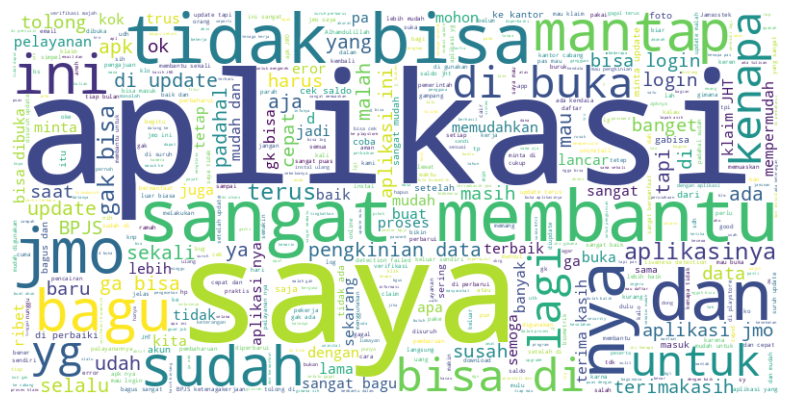

In [ ]:
import pandas as pd
import numpy as np
from PIL import Image
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
import matplotlib.pyplot as plt


# Mengisi nilai NaN dengan string kosong ('')
df['Review Text'] = df['Review Text'].fillna('')

# Menggabungkan teks dari kolom 'content'
text = ' '.join(df['Review Text'].astype(str).tolist())

stopwords = set(STOPWORDS)
stopwords.update(['https', 'co', 'RT', '...', 'amp'])

wc = WordCloud(stopwords=stopwords, background_color="white", max_words=500, width=800, height=400)

wc.generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.show()

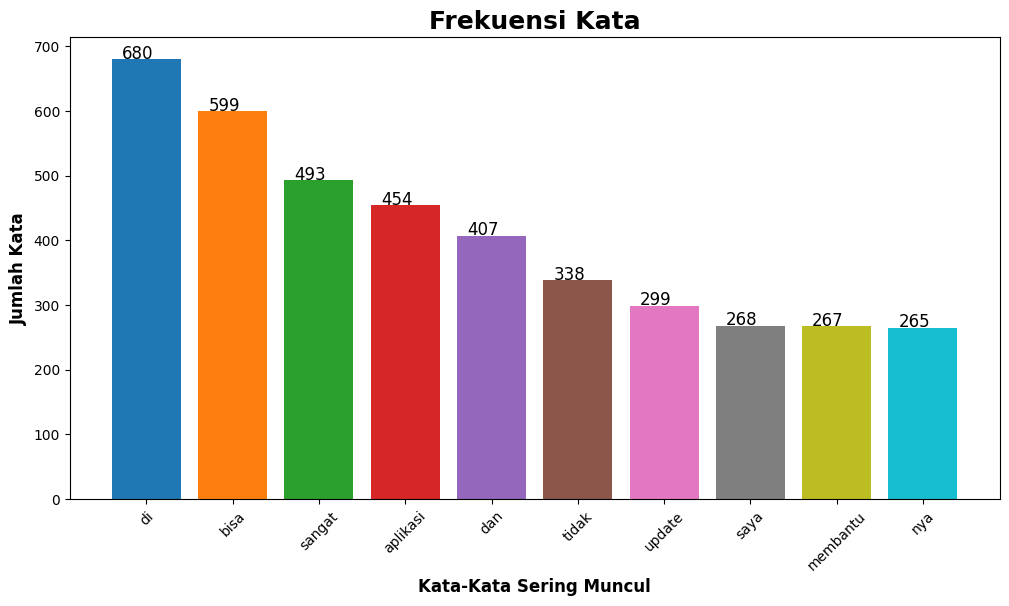

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter

text = " ".join(df["Review Text"])

tokens = text.split()
word_counts = Counter(tokens)

top_words = word_counts.most_common(10)

word, count = zip(*top_words)

# Definisikan palet warna
colors = plt.cm.tab10(range(len(word)))

plt.figure(figsize=(12, 6))
bars = plt.bar(word, count, color=colors)
plt.xlabel("Kata-Kata Sering Muncul", fontsize=12, fontweight='bold')
plt.ylabel("Jumlah Kata", fontsize=12, fontweight='bold')
plt.title("Frekuensi Kata", fontsize=18, fontweight='bold')
plt.xticks(rotation=45)

# Menambahkan angka rata tengah di atas setiap bar
for bar, num in zip(bars, count):
    plt.text(bar.get_x() + bar.get_width() / 2 - 0.1, num + 1, str(num), fontsize=12, color='black', ha='center')


plt.show()

**PROSES CLEANING**

---



In [ ]:
import re
import string
import nltk

# Fungsi untuk menghapus URL
def remove_URL(tweet):
    if tweet is not None and isinstance(tweet, str):
        url = re.compile(r'https?://\S+|www\.\S+')
        return url.sub(r'', tweet)
    else:
        return tweet

# Fungsi untuk menghapus HTML
def remove_html(tweet):
    if tweet is not None and isinstance(tweet, str):
        html = re.compile(r'<.*?>')
        return html.sub(r'', tweet)
    else:
        return tweet

# Fungsi untuk menghapus emoji
def remove_emoji(tweet):
    if tweet is not None and isinstance(tweet, str):
        emoji_pattern = re.compile("["
            u"\U0001F600-\U0001F64F"  # emoticons
            u"\U0001F300-\U0001F5FF"  # symbols & pictographs
            u"\U0001F680-\U0001F6FF"  # transport & map symbols
            u"\U0001F700-\U0001F77F"  # alchemical symbols
            u"\U0001F780-\U0001F7FF"  # Geometric Shapes Extended
            u"\U0001F800-\U0001F8FF"  # Supplemental Arrows-C
            u"\U0001F900-\U0001F9FF"  # Supplemental Symbols and Pictographs
            u"\U0001FA00-\U0001FA6F"  # Chess Symbols
            u"\U0001FA70-\U0001FAFF"  # Symbols and Pictographs Extended-A
            u"\U0001F004-\U0001F0CF"  # Additional emoticons
            u"\U0001F1E0-\U0001F1FF"  # flags
                               "]+", flags=re.UNICODE)
        return emoji_pattern.sub(r'', tweet)
    else:
        return tweet

# Fungsi untuk menghapus simbol
def remove_symbols(tweet):
    if tweet is not None and isinstance(tweet, str):
        tweet = re.sub(r'[^a-zA-Z0-9\s]', '', tweet)
    return tweet

# Fungsi untuk menghapus angka
def remove_numbers(tweet):
    if tweet is not None and isinstance(tweet, str):
        tweet = re.sub(r'\d', '', tweet)
    return tweet

df['cleaning'] = df['Review Text'].apply(lambda x: remove_URL(x))
df['cleaning'] = df['cleaning'].apply(lambda x: remove_html(x))
df['cleaning'] = df['cleaning'].apply(lambda x: remove_emoji(x))
df['cleaning'] = df['cleaning'].apply(lambda x: remove_symbols(x))
df['cleaning'] = df['cleaning'].apply(lambda x: remove_numbers(x))

df.head(5)

,Date,Username,Rating,Review Text,cleaning
0,2025-05-08 12:36:23,Pengguna Google,1,error terus uninstall udah 5× lebih,error terus uninstall udah lebih
1,2025-05-08 12:32:42,Pengguna Google,4,sering gangguan saat pengecek an,sering gangguan saat pengecek an
2,2025-05-08 12:31:13,Pengguna Google,5,"ok bermanfaat,sangat mudah tidak ribet terimak...",ok bermanfaatsangat mudah tidak ribet terimaka...
3,2025-05-08 12:29:22,Pengguna Google,5,sangat bagus,sangat bagus
4,2025-05-08 12:26:23,Pengguna Google,5,sangat puas,sangat puas


**PROSES CASE FOLDING**

---



In [ ]:
def case_folding(text):
    if isinstance(text, str):
        lowercase_text = text.lower()
        return lowercase_text
    else:
        return text

df['case_folding'] = df['cleaning'].apply(case_folding)
df.head(5)

,Date,Username,Rating,Review Text,cleaning,case_folding
0,2025-05-08 12:36:23,Pengguna Google,1,error terus uninstall udah 5× lebih,error terus uninstall udah lebih,error terus uninstall udah lebih
1,2025-05-08 12:32:42,Pengguna Google,4,sering gangguan saat pengecek an,sering gangguan saat pengecek an,sering gangguan saat pengecek an
2,2025-05-08 12:31:13,Pengguna Google,5,"ok bermanfaat,sangat mudah tidak ribet terimak...",ok bermanfaatsangat mudah tidak ribet terimaka...,ok bermanfaatsangat mudah tidak ribet terimaka...
3,2025-05-08 12:29:22,Pengguna Google,5,sangat bagus,sangat bagus,sangat bagus
4,2025-05-08 12:26:23,Pengguna Google,5,sangat puas,sangat puas,sangat puas


**Normalisasi Kata**

---



In [ ]:
import pandas as pd
import requests
from io import BytesIO

# Fungsi penggantian kata tidak baku
def replace_taboo_words(text, kamus_tidak_baku):
    if isinstance(text, str):
        words = text.split()
        replaced_words = []
        kalimat_baku = []
        kata_diganti = []
        kata_tidak_baku_hash = []

        for word in words:
            if word in kamus_tidak_baku:
                baku_word = kamus_tidak_baku[word]
                if isinstance(baku_word, str) and all(char.isalpha() for char in baku_word):
                    replaced_words.append(baku_word)
                    kalimat_baku.append(baku_word)
                    kata_diganti.append(word)
                    kata_tidak_baku_hash.append(hash(word))
            else:
                replaced_words.append(word)
        replaced_text = ' '.join(replaced_words)
    else:
        replaced_text = ''
        kalimat_baku = []
        kata_diganti = []
        kata_tidak_baku_hash = []

    return replaced_text, kalimat_baku, kata_diganti, kata_tidak_baku_hash

# Baca dataset kamu (pastikan df sudah tersedia)
data = pd.DataFrame(df[['Date','Username','Rating','Review Text','cleaning','case_folding']])
data.head()

,Date,Username,Rating,Review Text,cleaning,case_folding
0,2025-05-08 12:36:23,Pengguna Google,1,error terus uninstall udah 5× lebih,error terus uninstall udah lebih,error terus uninstall udah lebih
1,2025-05-08 12:32:42,Pengguna Google,4,sering gangguan saat pengecek an,sering gangguan saat pengecek an,sering gangguan saat pengecek an
2,2025-05-08 12:31:13,Pengguna Google,5,"ok bermanfaat,sangat mudah tidak ribet terimak...",ok bermanfaatsangat mudah tidak ribet terimaka...,ok bermanfaatsangat mudah tidak ribet terimaka...
3,2025-05-08 12:29:22,Pengguna Google,5,sangat bagus,sangat bagus,sangat bagus
4,2025-05-08 12:26:23,Pengguna Google,5,sangat puas,sangat puas,sangat puas


In [ ]:
# Unduh dan baca kamus dari GitHub
url = "https://github.com/analysisdatasentiment/kamus_kata_baku/raw/main/kamuskatabaku.xlsx"
response = requests.get(url)
file_excel = BytesIO(response.content)
kamus_data = pd.read_excel(file_excel)

# Buat dictionary dari kamus
kamus_tidak_baku_dict = dict(zip(kamus_data['tidak_baku'], kamus_data['kata_baku']))

In [ ]:
# Terapkan fungsi normalisasi
data[['normalisasi', 'Kata_Baku', 'Kata_Tidak_Baku', 'Kata_Tidak_Baku_Hash']] = data['case_folding'].apply(
    lambda x: pd.Series(replace_taboo_words(x, kamus_tidak_baku_dict))
)

# Ambil kolom yang relevan
df = pd.DataFrame(data[['Date','Username','Rating','Review Text','cleaning','case_folding','normalisasi']])
df.head(5)

,Date,Username,Rating,Review Text,cleaning,case_folding,normalisasi
0,2025-05-08 12:36:23,Pengguna Google,1,error terus uninstall udah 5× lebih,error terus uninstall udah lebih,error terus uninstall udah lebih,error terus uninstall sudah lebih
1,2025-05-08 12:32:42,Pengguna Google,4,sering gangguan saat pengecek an,sering gangguan saat pengecek an,sering gangguan saat pengecek an,sering gangguan saat pengecek an
2,2025-05-08 12:31:13,Pengguna Google,5,"ok bermanfaat,sangat mudah tidak ribet terimak...",ok bermanfaatsangat mudah tidak ribet terimaka...,ok bermanfaatsangat mudah tidak ribet terimaka...,ok bermanfaatsangat mudah tidak ribet terimaka...
3,2025-05-08 12:29:22,Pengguna Google,5,sangat bagus,sangat bagus,sangat bagus,sangat bagus
4,2025-05-08 12:26:23,Pengguna Google,5,sangat puas,sangat puas,sangat puas,sangat puas


**TOKENIZATION**

---



In [ ]:
def tokenize(text):
    tokens = text.split()
    return tokens

df['tokenize'] = df['normalisasi'].apply(tokenize)

df.head(5)

,Date,Username,Rating,Review Text,cleaning,case_folding,normalisasi,tokenize
0,2025-05-08 12:36:23,Pengguna Google,1,error terus uninstall udah 5× lebih,error terus uninstall udah lebih,error terus uninstall udah lebih,error terus uninstall sudah lebih,"[error, terus, uninstall, sudah, lebih]"
1,2025-05-08 12:32:42,Pengguna Google,4,sering gangguan saat pengecek an,sering gangguan saat pengecek an,sering gangguan saat pengecek an,sering gangguan saat pengecek an,"[sering, gangguan, saat, pengecek, an]"
2,2025-05-08 12:31:13,Pengguna Google,5,"ok bermanfaat,sangat mudah tidak ribet terimak...",ok bermanfaatsangat mudah tidak ribet terimaka...,ok bermanfaatsangat mudah tidak ribet terimaka...,ok bermanfaatsangat mudah tidak ribet terimaka...,"[ok, bermanfaatsangat, mudah, tidak, ribet, te..."
3,2025-05-08 12:29:22,Pengguna Google,5,sangat bagus,sangat bagus,sangat bagus,sangat bagus,"[sangat, bagus]"
4,2025-05-08 12:26:23,Pengguna Google,5,sangat puas,sangat puas,sangat puas,sangat puas,"[sangat, puas]"


**PROSES STOPWORD REMOVAL**

---



In [ ]:
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = stopwords.words('indonesian')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
def remove_stopwords(text):
    return [word for word in text if word not in stop_words]

df['stopword removal'] = df['tokenize'].apply(lambda x: remove_stopwords(x))

df.head(5)

,Date,Username,Rating,Review Text,cleaning,case_folding,normalisasi,tokenize,stopword removal
0,2025-05-08 12:36:23,Pengguna Google,1,error terus uninstall udah 5× lebih,error terus uninstall udah lebih,error terus uninstall udah lebih,error terus uninstall sudah lebih,"[error, terus, uninstall, sudah, lebih]","[error, uninstall]"
1,2025-05-08 12:32:42,Pengguna Google,4,sering gangguan saat pengecek an,sering gangguan saat pengecek an,sering gangguan saat pengecek an,sering gangguan saat pengecek an,"[sering, gangguan, saat, pengecek, an]","[gangguan, pengecek, an]"
2,2025-05-08 12:31:13,Pengguna Google,5,"ok bermanfaat,sangat mudah tidak ribet terimak...",ok bermanfaatsangat mudah tidak ribet terimaka...,ok bermanfaatsangat mudah tidak ribet terimaka...,ok bermanfaatsangat mudah tidak ribet terimaka...,"[ok, bermanfaatsangat, mudah, tidak, ribet, te...","[ok, bermanfaatsangat, mudah, ribet, terimakas..."
3,2025-05-08 12:29:22,Pengguna Google,5,sangat bagus,sangat bagus,sangat bagus,sangat bagus,"[sangat, bagus]",[bagus]
4,2025-05-08 12:26:23,Pengguna Google,5,sangat puas,sangat puas,sangat puas,sangat puas,"[sangat, puas]",[puas]


**PROSES STEAMING DATA**

---



In [ ]:
!pip install Sastrawi

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from nltk.stem import PorterStemmer
from nltk.stem.snowball import SnowballStemmer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 3.8 MB/s eta 0:00:00


In [ ]:
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stem_text(text):
    return [stemmer.stem(word) for word in text]

df['steming_data'] = df['stopword removal'].apply(lambda x: ' '.join(stem_text(x)))
df.head(5)

,Date,Username,Rating,Review Text,cleaning,case_folding,normalisasi,tokenize,stopword removal,steming_data
0,2025-05-08 12:36:23,Pengguna Google,1,error terus uninstall udah 5× lebih,error terus uninstall udah lebih,error terus uninstall udah lebih,error terus uninstall sudah lebih,"[error, terus, uninstall, sudah, lebih]","[error, uninstall]",error uninstall
1,2025-05-08 12:32:42,Pengguna Google,4,sering gangguan saat pengecek an,sering gangguan saat pengecek an,sering gangguan saat pengecek an,sering gangguan saat pengecek an,"[sering, gangguan, saat, pengecek, an]","[gangguan, pengecek, an]",ganggu ecek an
2,2025-05-08 12:31:13,Pengguna Google,5,"ok bermanfaat,sangat mudah tidak ribet terimak...",ok bermanfaatsangat mudah tidak ribet terimaka...,ok bermanfaatsangat mudah tidak ribet terimaka...,ok bermanfaatsangat mudah tidak ribet terimaka...,"[ok, bermanfaatsangat, mudah, tidak, ribet, te...","[ok, bermanfaatsangat, mudah, ribet, terimakas...",ok bermanfaatsangat mudah ribet terimakasih jmo
3,2025-05-08 12:29:22,Pengguna Google,5,sangat bagus,sangat bagus,sangat bagus,sangat bagus,"[sangat, bagus]",[bagus],bagus
4,2025-05-08 12:26:23,Pengguna Google,5,sangat puas,sangat puas,sangat puas,sangat puas,"[sangat, puas]",[puas],puas


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2930 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Date              2930 non-null   object
 1   Username          2930 non-null   object
 2   Rating            2930 non-null   int64 
 3   Review Text       2930 non-null   object
 4   cleaning          2930 non-null   object
 5   case_folding      2930 non-null   object
 6   normalisasi       2930 non-null   object
 7   tokenize          2930 non-null   object
 8   stopword removal  2930 non-null   object
 9   steming_data      2930 non-null   object
dtypes: int64(1), object(9)
memory usage: 316.3+ KB


**PROSES HAPUS DATA BERNILAI KOSONG (NAN)**

---



In [ ]:
data = df.dropna()
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2930 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Date              2930 non-null   object
 1   Username          2930 non-null   object
 2   Rating            2930 non-null   int64 
 3   Review Text       2930 non-null   object
 4   cleaning          2930 non-null   object
 5   case_folding      2930 non-null   object
 6   normalisasi       2930 non-null   object
 7   tokenize          2930 non-null   object
 8   stopword removal  2930 non-null   object
 9   steming_data      2930 non-null   object
dtypes: int64(1), object(9)
memory usage: 316.3+ KB


**WORDCLOUD SETELAH PREPROCESSING**

---



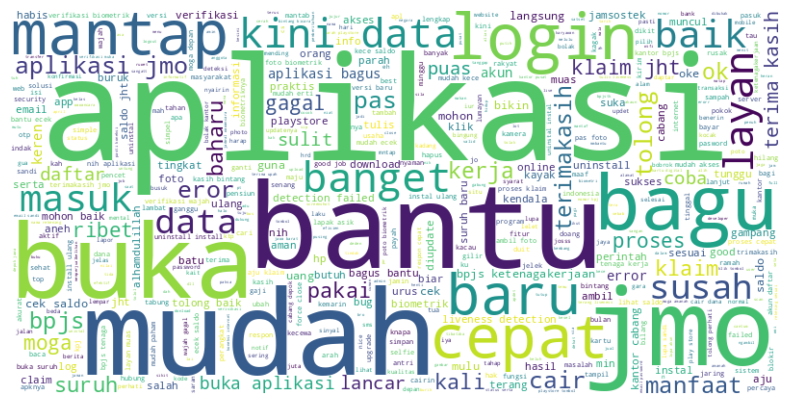

In [ ]:
import pandas as pd
import numpy as np
from PIL import Image
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
import matplotlib.pyplot as plt

# Menggabungkan teks dari kolom 'steming_data'
text = ' '.join(df['steming_data'].astype(str).tolist())

stopwords = set(STOPWORDS)
stopwords.update(['https', 'co', 'RT', '...', 'amp','lu','deh','fyp', 'ya', 'gue', 'sih','update','apk'])

wc = WordCloud(stopwords=stopwords, background_color="white", max_words=500, width=800, height=400)

wc.generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.show()

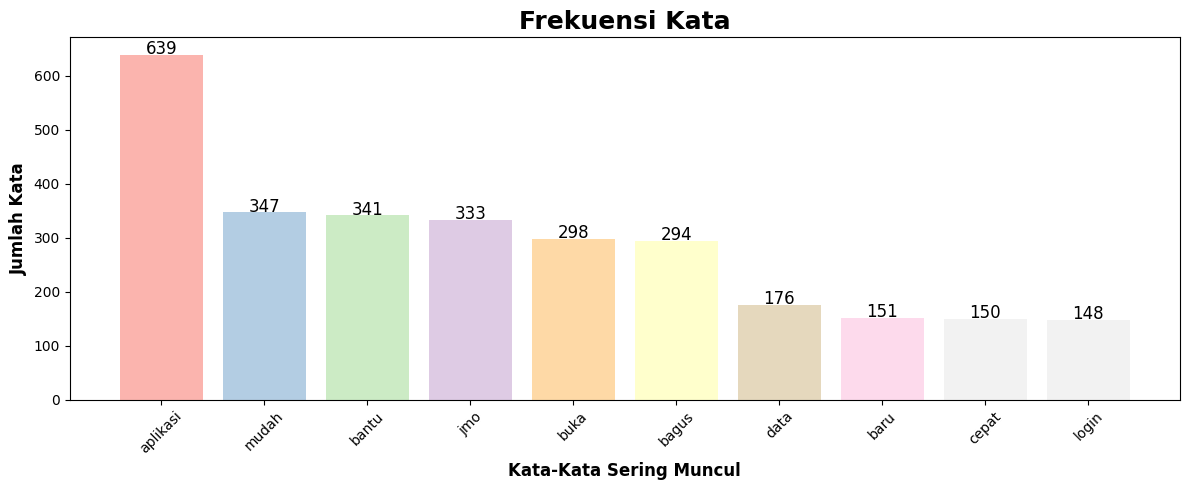

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import STOPWORDS

all_text = ' '.join(df["steming_data"].astype(str))
all_words = all_text.split()


stopwords = set(STOPWORDS)
stopwords.update(['https', 'co', 'RT', '...', 'amp', 'lu', 'deh', 'fyp', 'ya', 'gue',
                  'sih', 'yg', 'nya', 'aja', 'sdh', 'gak', 'ga','update','apk'])

filtered_words = [word for word in all_words if word.lower() not in stopwords]
word_counts = Counter(filtered_words)
top_words = word_counts.most_common(10)
word, count = zip(*top_words)

colors = plt.cm.Pastel1(range(len(word)))

# Plot
plt.figure(figsize=(12, 5))
bars = plt.bar(word, count, color=colors)
plt.xlabel("Kata-Kata Sering Muncul", fontsize=12, fontweight='bold')
plt.ylabel("Jumlah Kata", fontsize=12, fontweight='bold')
plt.title("Frekuensi Kata", fontsize=18, fontweight='bold')
plt.xticks(rotation=45)

# Tampilkan jumlah di atas bar
for bar, num in zip(bars, count):
    plt.text(bar.get_x() + bar.get_width() / 2, num + 1, str(num), fontsize=12, color='black', ha='center')

plt.tight_layout()
plt.show()

In [ ]:
df.to_csv('Hasil_Preprocessing_Data.csv',encoding='utf8', index=False);

# ***PELEBALAN DATA***

In [ ]:
import pandas as pd

data = pd.read_csv("Hasil_Preprocessing_Data.csv")
data.info()
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Date              2930 non-null   object
 1   Username          2930 non-null   object
 2   Rating            2930 non-null   int64 
 3   Review Text       2930 non-null   object
 4   cleaning          2914 non-null   object
 5   case_folding      2914 non-null   object
 6   normalisasi       2909 non-null   object
 7   tokenize          2930 non-null   object
 8   stopword removal  2930 non-null   object
 9   steming_data      2869 non-null   object
dtypes: int64(1), object(9)
memory usage: 229.0+ KB


,Date,Username,Rating,Review Text,cleaning,case_folding,normalisasi,tokenize,stopword removal,steming_data
0,2025-05-08 12:36:23,Pengguna Google,1,error terus uninstall udah 5× lebih,error terus uninstall udah lebih,error terus uninstall udah lebih,error terus uninstall sudah lebih,"['error', 'terus', 'uninstall', 'sudah', 'lebih']","['error', 'uninstall']",error uninstall
1,2025-05-08 12:32:42,Pengguna Google,4,sering gangguan saat pengecek an,sering gangguan saat pengecek an,sering gangguan saat pengecek an,sering gangguan saat pengecek an,"['sering', 'gangguan', 'saat', 'pengecek', 'an']","['gangguan', 'pengecek', 'an']",ganggu ecek an
2,2025-05-08 12:31:13,Pengguna Google,5,"ok bermanfaat,sangat mudah tidak ribet terimak...",ok bermanfaatsangat mudah tidak ribet terimaka...,ok bermanfaatsangat mudah tidak ribet terimaka...,ok bermanfaatsangat mudah tidak ribet terimaka...,"['ok', 'bermanfaatsangat', 'mudah', 'tidak', '...","['ok', 'bermanfaatsangat', 'mudah', 'ribet', '...",ok bermanfaatsangat mudah ribet terimakasih jmo
3,2025-05-08 12:29:22,Pengguna Google,5,sangat bagus,sangat bagus,sangat bagus,sangat bagus,"['sangat', 'bagus']",['bagus'],bagus
4,2025-05-08 12:26:23,Pengguna Google,5,sangat puas,sangat puas,sangat puas,sangat puas,"['sangat', 'puas']",['puas'],puas


In [ ]:
data = data.dropna()
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2869 entries, 0 to 2929
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Date              2869 non-null   object
 1   Username          2869 non-null   object
 2   Rating            2869 non-null   int64 
 3   Review Text       2869 non-null   object
 4   cleaning          2869 non-null   object
 5   case_folding      2869 non-null   object
 6   normalisasi       2869 non-null   object
 7   tokenize          2869 non-null   object
 8   stopword removal  2869 non-null   object
 9   steming_data      2869 non-null   object
dtypes: int64(1), object(9)
memory usage: 246.6+ KB


In [ ]:
data = pd.DataFrame(data[['steming_data']])
data.head(5)

,steming_data
0,error uninstall
1,ganggu ecek an
2,ok bermanfaatsangat mudah ribet terimakasih jmo
3,bagus
4,puas


In [ ]:
import pandas as pd
import requests

# Unduh kamus leksikon positif dan negatif dari GitHub
positive_url = "https://raw.githubusercontent.com/fajri91/InSet/master/positive.tsv"
negative_url = "https://raw.githubusercontent.com/fajri91/InSet/master/negative.tsv"

positive_lexicon = set(pd.read_csv(positive_url, sep="\t", header=None)[0])
negative_lexicon = set(pd.read_csv(negative_url, sep="\t", header=None)[0])

# Fungsi untuk menentukan sentimen dan menghitung skornya
def determine_sentiment(text):
    if isinstance(text, str):
        positive_count = sum(1 for word in text.split() if word in positive_lexicon)
        negative_count = sum(1 for word in text.split() if word in negative_lexicon)
        sentiment_score = positive_count - negative_count
        if sentiment_score > 0:
            sentiment = "Positif"
        elif sentiment_score < 0:
            sentiment = "Negatif"
        else:
            sentiment = "Netral"
        return sentiment_score, sentiment
    return 0, "Netral"


# Tentukan sentimen dan skor untuk setiap ulasan
data[['Score', 'Sentiment']] = data['steming_data'].apply(lambda x: pd.Series(determine_sentiment(x)))

# Tampilkan hasilnya
data.head(5)


,steming_data,Score,Sentiment
0,error uninstall,-1,Negatif
1,ganggu ecek an,-1,Negatif
2,ok bermanfaatsangat mudah ribet terimakasih jmo,1,Positif
3,bagus,0,Netral
4,puas,1,Positif


<ipython-input-47-460eb42ca53d>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=sentiment_count.index, y=sentiment_count.values, palette='pastel')


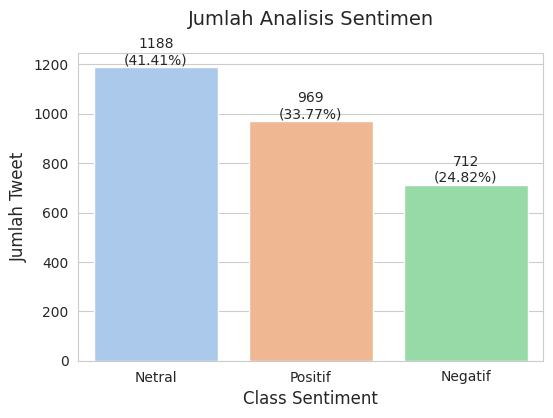

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sentiment_count = data['Sentiment'].value_counts()
sns.set_style('whitegrid')

fig, ax = plt.subplots(figsize=(6, 4))
ax = sns.barplot(x=sentiment_count.index, y=sentiment_count.values, palette='pastel')
plt.title('Jumlah Analisis Sentimen', fontsize=14, pad=20)
plt.xlabel('Class Sentiment', fontsize=12)
plt.ylabel('Jumlah Tweet', fontsize=12)

total = len(data['Sentiment'])

for i, count in enumerate(sentiment_count.values):
    percentage = f'{100 * count / total:.2f}%'
    ax.text(i, count + 0.10, f'{count}\n({percentage})', ha='center', va='bottom')

plt.show()

In [ ]:
data.to_csv('Hasil_Labelling_Data.csv',encoding='utf8', index=False)

**WORDCLOUD**

---



In [ ]:
import pandas as pd

data = pd.read_csv("Hasil_Labelling_Data.csv")
data.head(5)

,steming_data,Score,Sentiment
0,error uninstall,-1,Negatif
1,ganggu ecek an,-1,Negatif
2,ok bermanfaatsangat mudah ribet terimakasih jmo,1,Positif
3,bagus,0,Netral
4,puas,1,Positif


In [ ]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Pisahkan dataset berdasarkan sentimen
sentimen_Neutral = data[data['Sentiment'] == 'Netral']['steming_data'].str.cat(sep=' ')
sentimen_Negative = data[data['Sentiment'] == 'Negatif']['steming_data'].str.cat(sep=' ')
sentimen_Positive = data[data['Sentiment'] == 'Positif']['steming_data'].str.cat(sep=' ')

In [ ]:
# Fungsi untuk membuat dan menampilkan WordCloud
def create_wordcloud(text, title):
    wordcloud = WordCloud(width=800, height=400, random_state=42, max_font_size=100, background_color='white').generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

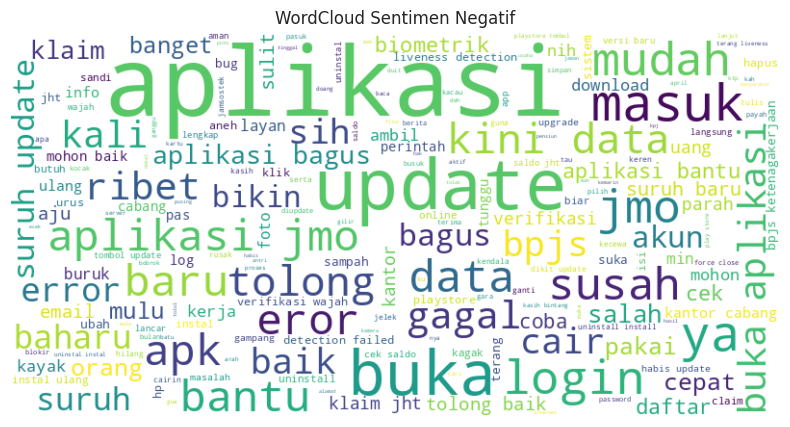

In [ ]:
# Membuat WordCloud untuk sentimen Negatif
create_wordcloud(sentimen_Negative, 'WordCloud Sentimen Negatif')

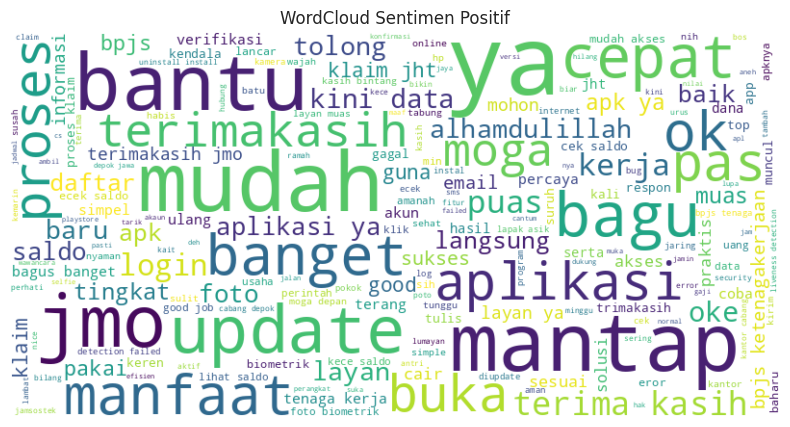

In [ ]:
# Membuat WordCloud untuk sentimen Positif
create_wordcloud(sentimen_Positive, 'WordCloud Sentimen Positif')

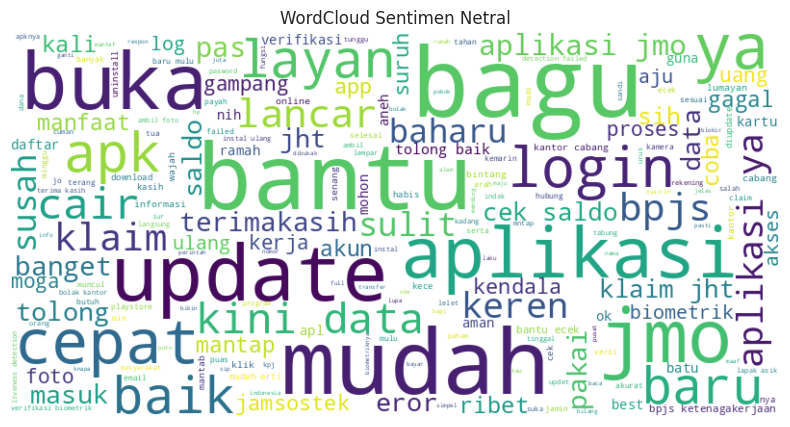

In [ ]:
# Membuat WordCloud untuk sentimen Netral
create_wordcloud(sentimen_Neutral, 'WordCloud Sentimen Netral')

# ***Splitting Data***

In [ ]:
!pip install xgboost scikit-learn seaborn
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [ ]:
import pandas as pd

file_path = 'Hasil_Labelling_Data.csv'
data = pd.read_csv(file_path)

data.info()
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2869 entries, 0 to 2868
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   steming_data  2869 non-null   object
 1   Score         2869 non-null   int64 
 2   Sentiment     2869 non-null   object
dtypes: int64(1), object(2)
memory usage: 67.4+ KB


,steming_data,Score,Sentiment
0,error uninstall,-1,Negatif
1,ganggu ecek an,-1,Negatif
2,ok bermanfaatsangat mudah ribet terimakasih jmo,1,Positif
3,bagus,0,Netral
4,puas,1,Positif


In [ ]:
label_encoder = LabelEncoder()
data['Sentiment_encoded'] = label_encoder.fit_transform(data['Sentiment'])
tfidf = TfidfVectorizer(max_features=300)
X = tfidf.fit_transform(data['steming_data']).toarray()
y = data['Sentiment_encoded']

print(X.shape)
print(y.shape)

(2869, 300)
(2869,)


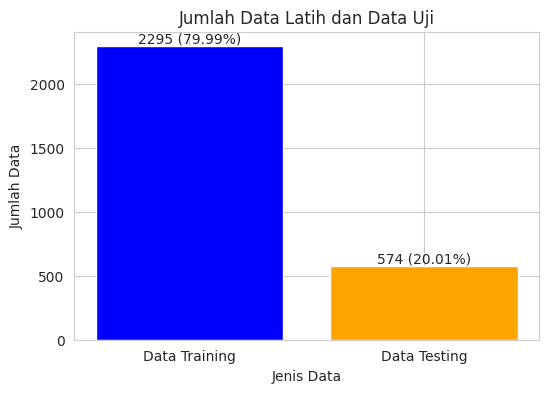

In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

train_size = len(X_train)
test_size = len(X_test)

plt.figure(figsize=(6, 4))
bars = plt.bar(['Data Training', 'Data Testing'], [train_size, test_size], color=['blue', 'orange'])

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height} ({height / (train_size + test_size) * 100:.2f}%)',
             ha='center', va='bottom')

plt.title('Jumlah Data Latih dan Data Uji')
plt.xlabel('Jenis Data')
plt.ylabel('Jumlah Data')
plt.show()

# ***Algoritma XGBoost***

In [ ]:
model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', max_depth=8, n_estimators=200)
model.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [13:12:16] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, objective='multi:softprob', ...)

In [ ]:
#Predictions and Evaluation
y_pred = model.predict(X_test)

In [ ]:
# Confusion Matrix and Classification Report
conf_matrix = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2%}')
print('Classification Report:\n', classification_report(y_test, y_pred, target_names=label_encoder.classes_))

Accuracy: 83.45%
Classification Report:
               precision    recall  f1-score   support

     Negatif       0.82      0.75      0.78       142
      Netral       0.80      0.86      0.83       238
     Positif       0.90      0.86      0.88       194

    accuracy                           0.83       574
   macro avg       0.84      0.83      0.83       574
weighted avg       0.84      0.83      0.83       574



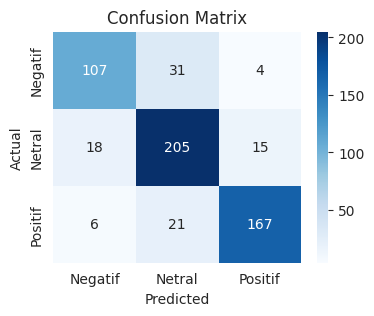

In [ ]:
# Plotting Confusion Matrix
plt.figure(figsize=(4, 3))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title(f'Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ***RANTING***

In [ ]:
import pandas as pd

data = pd.read_csv("Hasil_Preprocessing_Data.csv")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Date              2930 non-null   object
 1   Username          2930 non-null   object
 2   Rating            2930 non-null   int64 
 3   Review Text       2930 non-null   object
 4   cleaning          2914 non-null   object
 5   case_folding      2914 non-null   object
 6   normalisasi       2909 non-null   object
 7   tokenize          2930 non-null   object
 8   stopword removal  2930 non-null   object
 9   steming_data      2869 non-null   object
dtypes: int64(1), object(9)
memory usage: 229.0+ KB


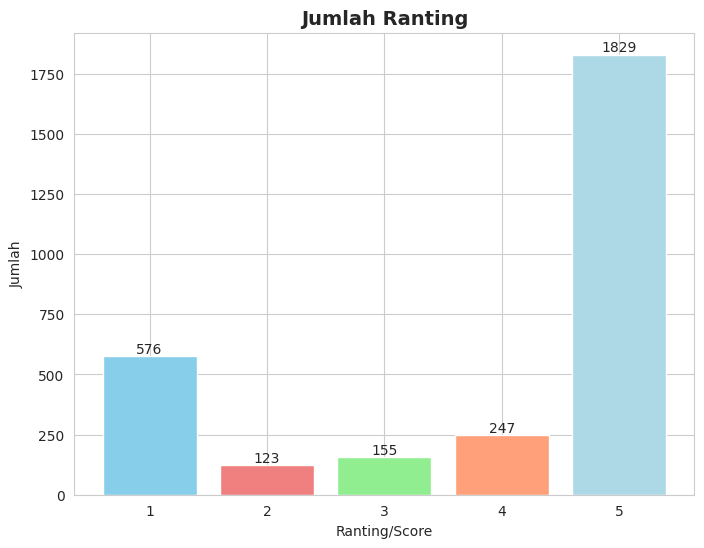

In [ ]:
import matplotlib.pyplot as plt

rating_counts = data['Rating'].value_counts()
rating_counts = rating_counts.sort_index()

colors = ['skyblue', 'lightcoral', 'lightgreen', 'lightsalmon', 'lightblue']

plt.figure(figsize=(8, 6))
bars = plt.bar(rating_counts.index, rating_counts.values, color=colors)
plt.title('Jumlah Ranting', fontsize=14, fontweight='bold')
plt.xlabel('Ranting/Score')
plt.ylabel('Jumlah')
plt.xticks(rating_counts.index)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, str(int(height)), ha='center', va='bottom')

plt.show()